In [1]:
# The code in this block comes directly from data_sort_and_split.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

heart_data = pd.read_csv("heart.csv")
heart_data['Sex_F'] = heart_data['Sex'].map({'M': 0, 'F': 1})
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'N': 0, 'Y': 1})
heart_data = heart_data.drop(columns=['Sex'])
heart_data['ChestPainType'] = pd.Categorical(heart_data['ChestPainType'], categories=['ASY', 'ATA', 'NAP', 'TA'])
heart_data['RestingECG'] = pd.Categorical(heart_data['RestingECG'], categories=['Normal', 'LVH', 'ST'])
heart_data['ST_Slope'] = pd.Categorical(heart_data['ST_Slope'], categories=['Up', 'Flat', 'Down'])
categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True, dtype=int)

feature_matrix = heart_data.drop("HeartDisease", axis=1)
target_labels = heart_data["HeartDisease"]
feature_names = list(feature_matrix.columns)

features_train, features_test, targets_train, targets_test = train_test_split(
    feature_matrix,
    target_labels,
    test_size=0.20,
    random_state=42,
    stratify=target_labels
)

# Why: Scaling is fitted on training data only to prevent data leakage from the test set.
# Why: Only needed for Logistic Regression and SVM, not tree based models.
scaler = StandardScaler()
scaler.fit(features_train)
features_train_scaled = scaler.transform(features_train)
features_test_scaled = scaler.transform(features_test)

In [2]:
# Why: We retrain all four models that support feature importance so we can
# compare which features each model considers most important.
dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_impurity_decrease=0.01, min_samples_split=2, class_weight='balanced', random_state=42)
dt.fit(features_train, targets_train)

rf = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=10, max_features='sqrt', bootstrap=True, class_weight='balanced', random_state=42)
rf.fit(features_train, targets_train)

lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(features_train_scaled, targets_train)

svm = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
svm.fit(features_train_scaled, targets_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


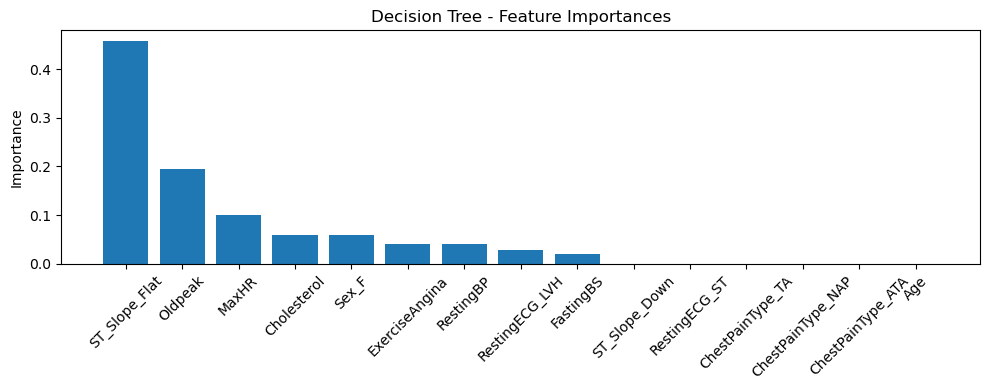

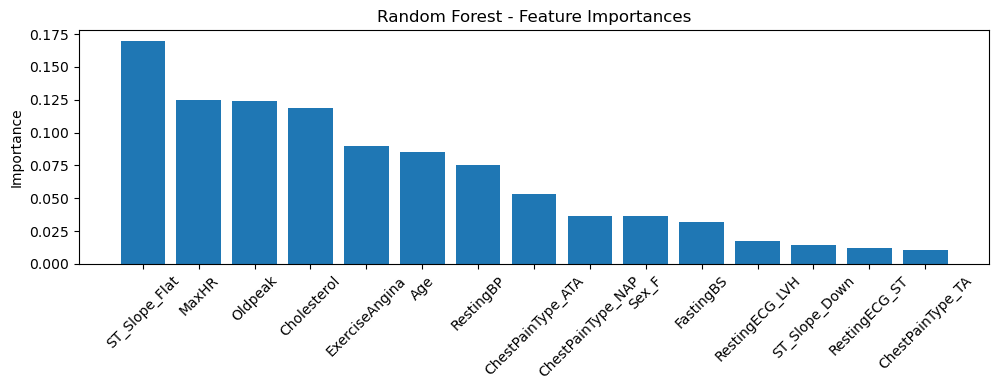

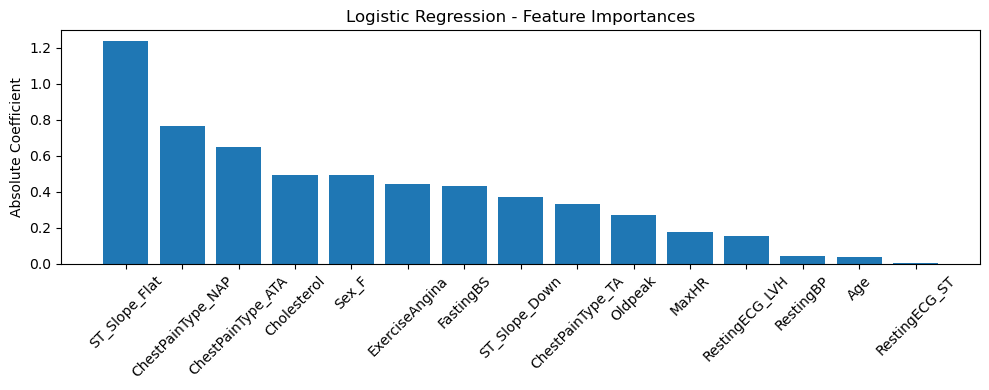

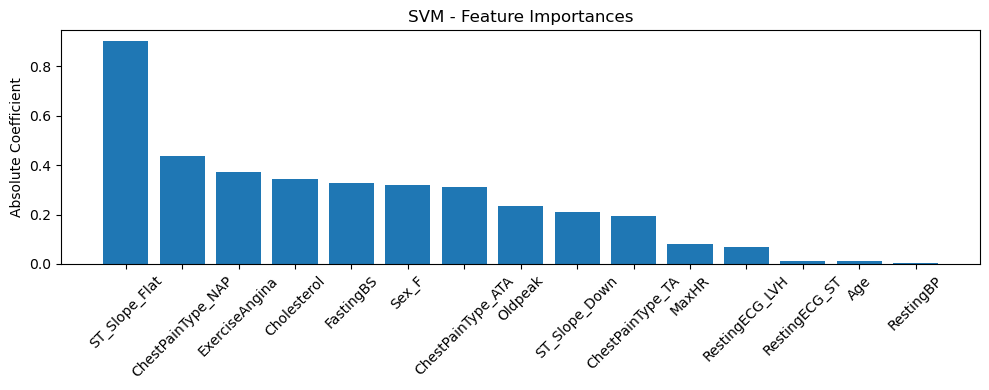

In [3]:
# Why: We extract feature importances from each model to compare which patient
# symptoms each model considers most important for predicting heart disease.
dt_imp = dt.feature_importances_
rf_imp = rf.feature_importances_
lr_imp = np.abs(lr.coef_[0])
svm_imp = np.abs(svm.coef_[0])

# Why: We sort each model's importances in descending order so the most
# significant features always appear first in each chart.
dt_idx = np.argsort(dt_imp)[::-1]
rf_idx = np.argsort(rf_imp)[::-1]
lr_idx = np.argsort(lr_imp)[::-1]
svm_idx = np.argsort(svm_imp)[::-1]

# Decision Tree
plt.figure(figsize=(10, 4))
plt.bar(x=[feature_names[i] for i in dt_idx], height=dt_imp[dt_idx])
plt.title('Decision Tree - Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Random Forest
plt.figure(figsize=(10, 4))
plt.bar(x=[feature_names[i] for i in rf_idx], height=rf_imp[rf_idx])
plt.title('Random Forest - Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Logistic Regression
plt.figure(figsize=(10, 4))
plt.bar(x=[feature_names[i] for i in lr_idx], height=lr_imp[lr_idx])
plt.title('Logistic Regression - Feature Importances')
plt.ylabel('Absolute Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SVM
plt.figure(figsize=(10, 4))
plt.bar(x=[feature_names[i] for i in svm_idx], height=svm_imp[svm_idx])
plt.title('SVM - Feature Importances')
plt.ylabel('Absolute Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()